In [1]:
using Ferrite
using ModularEIT
using Images
using IterativeSolvers
using LinearAlgebra
using Plots
using Distributions
using Statistics
using Lux
using JLD2

In [2]:
include("model/sde.jl")
sde(randn(64,64),1)

64×64 Matrix{Float32}:
 -0.54524   -1.31397    -0.435752   …   1.30254   -0.6212    -0.207157
 -0.663477   0.216115    1.09056       -0.564844   0.214842   3.04432
  0.800261   0.392289    0.900165       0.492563  -0.784302   0.0841507
  0.765863  -0.863283    1.68948       -0.942332  -1.44419   -1.29781
  0.343592  -0.346176   -1.56066       -1.14133   -0.405793   0.065309
 -0.10313   -1.16027     0.795933   …   0.498428  -0.8226     0.0489604
  0.44968   -1.6391      0.0960265      0.750483  -2.24517   -0.0584983
  0.82888    0.0186713  -0.251913      -0.990749  -1.19321   -3.6509
 -1.13619   -0.0783252  -0.839623       0.15506    0.67161   -0.364827
  0.684132  -1.52496     0.701304       1.03982    0.705731   0.375033
  ⋮                                 ⋱                        
 -0.50664    0.18288     1.63628    …  -0.947548   0.926566  -0.0148311
 -0.422326  -1.97388     0.419312      -0.512245  -0.799976   0.248402
 -1.24452   -0.0399208  -0.306567       0.778714  -0.109217  -0

Now we need to differentiate the model:

In [3]:
η = 0.15

σf = 0.0e-2 # how much noise is added to f
σg = 0.0e-2 # How much noise is added to g

0.0

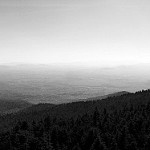

In [4]:
img = load("1096.jpg")

In [5]:
itp = interpolate_array_2D(Float64.(img))

#interpolate_array_2D##0 (generic function with 1 method)

In [6]:
n = 63 
grid = generate_grid(Quadrilateral, (n, n));
∂Ω = union(getfacetset.((grid,), ["left", "top", "right", "bottom"])...)
fe  = FerriteFESpace{RefQuadrilateral}(grid,2,3,∂Ω)
cond_vec = project_function_to_fem(fe, itp)
cond_vec .= min.(max.(cond_vec,1e-6),1.0)

16129-element Vector{Float64}:
 0.662071948030728
 0.6844350473112837
 0.6927977157805238
 0.6702852217531009
 0.6757136120745573
 0.6894434399964395
 0.68419175360409
 0.6672001101490135
 0.6806489158672026
 0.6971524452344504
 ⋮
 0.031167250350174577
 0.015510000235997853
 0.014520427059962128
 0.007829287198868289
 0.00883805925916716
 0.008600073232173745
 0.014341377282337255
 0.012685658965159618
 0.019464199801231867

In [7]:
G_full = real_fourier_basis(8)
rhs_dict = Dict()
Threads.@threads for i in 2:256
    M = make_boundary(G_full[:, i],64)
    itp = interpolate_array_2D(M)
    rhs_dict[i] = assemble_rhs_func(fe, itp)
end

In [8]:
K = assemble_L(fe, cond_vec)
K_fac = cholesky(K)
mode_dict = Dict{Int64,FerriteEITMode}()
mode_dict_no_noise = Dict{Int64,FerriteEITMode}()
@time begin
    Threads.@threads for i in 2:256
        mode_dict[i-1] = create_mode_from_g(fe, rhs_dict[i], K_fac, normalize =  true, σ_f = σf, σ_g= σg)
        mode_dict_no_noise[i-1] = create_mode_from_g(fe, rhs_dict[i], K_fac, normalize =  true)
    end
end

  1.071907 seconds (671.64 k allocations: 853.558 MiB, 31.81% gc time, 20.13% compilation time)


In [9]:
using Distributions
σ_vec = rand(Uniform(1e-6, 1.0), fe.n)
sol = FerriteSolverState(fe, σ_vec)
prblm = FerriteProblem(fe, mode_dict, sol)

FerriteProblem(FerriteFESpace{RefQuadrilateral}(CellValues{Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 2}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}, Ferrite.GeometryMapping{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Nothing}, QuadratureRule{RefQuadrilateral, Vector{Float64}, Vector{Vec{2, Float64}}}, Vector{Float64}}(Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 2}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}(Lagrange{RefQuadrilateral, 2}(), [0.47237900077244527 -1.4605338811812958e-17 … 1.8551212633834227e-18 0.007620999227554982; -0.05999999999999999 1.4605338811812958e-17 … -1.8551212633834227e-18 -0.059999999999999984; … ; 0.2749193338482966 -8.50014503228635e-18 … -8.500145032286352e-18 -0.03491933384829665; 0.15999999999999984 0.3999999999999998 … 0.3999999999999999 0.15999999999999992], [0.47237900077244527 -1.4605338811812958e-17 … 1.855121263383

In [10]:
eval_points = reshape(equidistant_grid(64), :)
ph = PointEvalHandler(grid, eval_points)

PointEvalHandler{Grid{2, Quadrilateral, Float64}, Float64}
  number of points: 4096
  Found corresponding cell for all points.

In [11]:
f,∂f = create_f∂f(prblm, 255; gn=true)

(ModularEIT.var"#57#58"{String, typeof(objective_neumann_init!), Bool, FerriteProblem, Int64, Base.RefValue{Bool}}("neumann", ModularEIT.objective_neumann_init!, true, FerriteProblem(FerriteFESpace{RefQuadrilateral}(CellValues{Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 2}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}, Ferrite.GeometryMapping{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Nothing}, QuadratureRule{RefQuadrilateral, Vector{Float64}, Vector{Vec{2, Float64}}}, Vector{Float64}}(Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 2}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}(Lagrange{RefQuadrilateral, 2}(), [0.47237900077244527 -1.4605338811812958e-17 … 1.8551212633834227e-18 0.007620999227554982; -0.05999999999999999 1.4605338811812958e-17 … -1.8551212633834227e-18 -0.059999999999999984; … ; 0.2749193338482966 -8.50014503228635e-18 … -8.500145032286352e-

In [12]:
function grad_A(x)
    # convert to Float 64 and shift:
    xf64 = Float64.(denormalize_image(x))
    itp64 = interpolate_array_2D(xf64)
    σ64 = project_function_to_fem(fe, itp64)
    ∂f(σ64) 
    img64 = reshape(evaluate_at_points(ph, prblm.fe.dh, ∂f(σ64)),(64,64))
    Float32.(normalize_image(img64))
end
function obj_A(x)
    # convert to Float 64 and shift:
    xf64 = Float64.(denormalize_image(x))
    itp64 = interpolate_array_2D(xf64)
    σ64 = project_function_to_fem(fe, itp64)
    f(σ64)
end

obj_A (generic function with 1 method)

In [13]:
function sample_step!(μ,model,A,∂A,λ,τ)
    #sample t ∈ [0,T]
    t = rand(Uniform(0, T))
    αbar = ᾱ(t)
    #sample ϵ
    ε = randn(size(μ))
    # Forward evaluate:
    xt = sqrt(αbar) .* μ .+ sqrt(1 - αbar) .* ε
    ϵ_pred = model(xt,t)

    obj_A = A(μ)
    obj_diff =  dot(ϵ_pred - ε, μ)  
    obj = obj_A + λ * obj_diff
    
    grad_A = ∂A(μ)
    grad_diff = ϵ_pred - ε
    grad = grad_A .+ λ .* grad_diff
    μ_new = μ - τ * grad
    return μ_new, t, obj, obj_A, obj_diff
end

sample_step! (generic function with 1 method)